**Assignment: Medical Insurance Cost – EDA & Visualization**

Section 8 – EDA and Visualization

Goal:
- Understand the Medical Insurance dataset using basic EDA and plots.

Rules:
- No ML models
- No feature engineering
- Only Pandas, Matplotlib, Seaborn

In [13]:
# install the required packages
%pip install numpy pandas matplotlib seaborn -q


[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [14]:
# 1. Load Libraries & Dataset
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

DATASET_PATH = "insurance.csv"  # update path if needed
df = pd.read_csv(DATASET_PATH)

print("Dataset Loaded Successfully")

Dataset Loaded Successfully


In [15]:
# 2. Basic Inspection
print("\nShape of dataset:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nFirst 5 rows:")
display(df.head())


Shape of dataset: (1338, 7)

Column names:
['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges']

Data types:
age           int64
sex             str
bmi         float64
children      int64
smoker          str
region          str
charges     float64
dtype: object

First 5 rows:


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [16]:
# 3. Missing Values & Duplicates
print("\nMissing values per column:")
print(df.isnull().sum())

print("\nDuplicate rows count:")
print(df.duplicated().sum())


Missing values per column:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Duplicate rows count:
1


In [17]:
# 4. Numerical Feature Analysis
num_cols = ["age", "bmi", "children", "charges"]

print("Summary statistics:")
print(df[num_cols].describe())

Summary statistics:
               age          bmi     children       charges
count  1338.000000  1338.000000  1338.000000   1338.000000
mean     39.207025    30.663397     1.094918  13270.422265
std      14.049960     6.098187     1.205493  12110.011237
min      18.000000    15.960000     0.000000   1121.873900
25%      27.000000    26.296250     0.000000   4740.287150
50%      39.000000    30.400000     1.000000   9382.033000
75%      51.000000    34.693750     2.000000  16639.912515
max      64.000000    53.130000     5.000000  63770.428010


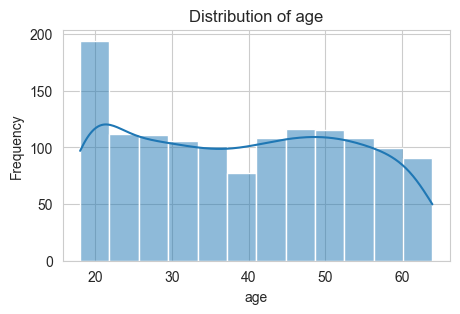

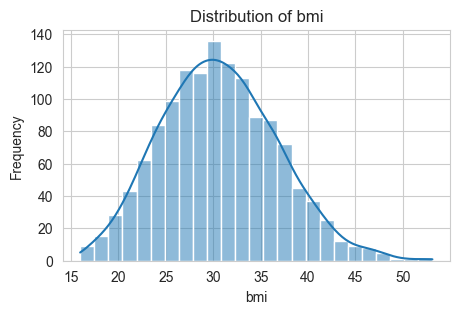

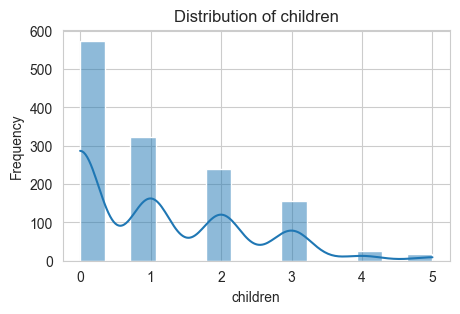

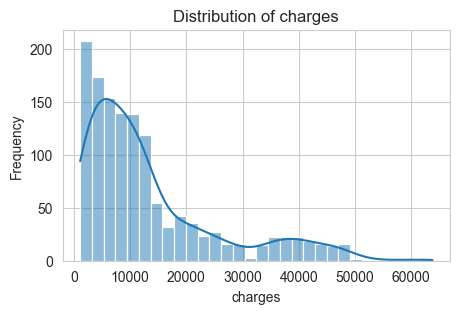

In [18]:
# 5. Distribution Plots
for col in num_cols:
    plt.figure(figsize=(5, 3))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

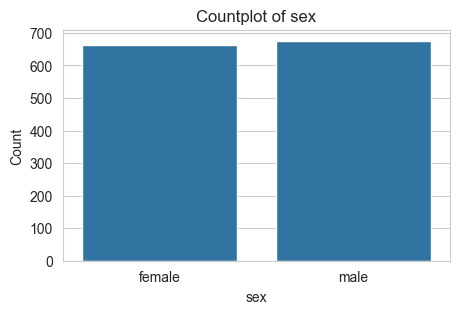

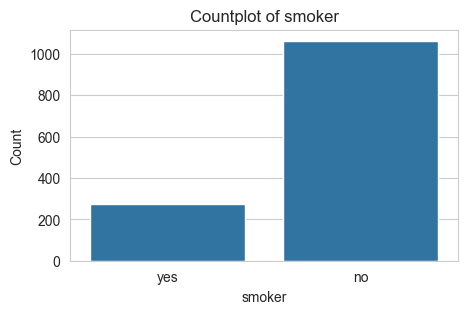

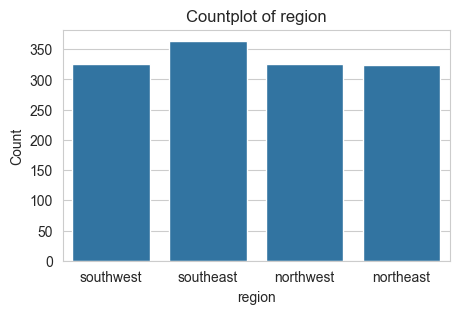

In [19]:
# 6. Categorical Feature Analysis
cat_cols = ["sex", "smoker", "region"]

for col in cat_cols:
    plt.figure(figsize=(5, 3))
    sns.countplot(x=df[col])
    plt.title(f"Countplot of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()

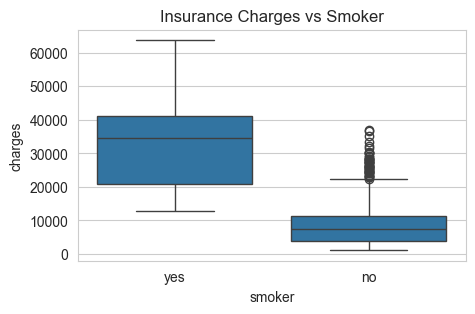

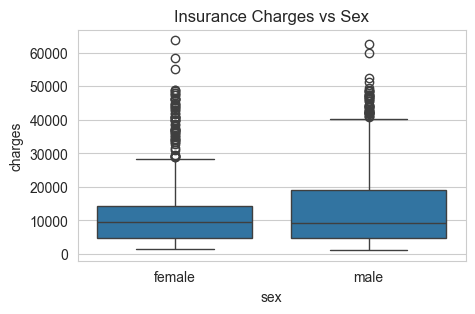

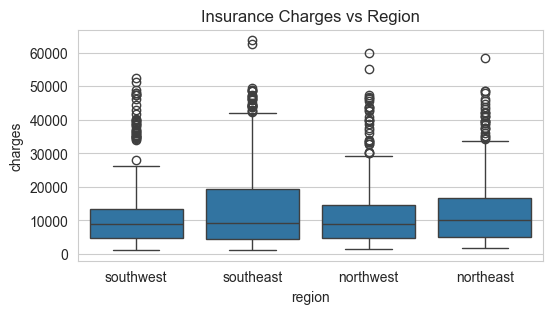

In [20]:
# 7. Relationship with Charges
# Charges vs Smoker
plt.figure(figsize=(5, 3))
sns.boxplot(x=df["smoker"], y=df["charges"])
plt.title("Insurance Charges vs Smoker")
plt.show()

# Charges vs Sex
plt.figure(figsize=(5, 3))
sns.boxplot(x=df["sex"], y=df["charges"])
plt.title("Insurance Charges vs Sex")
plt.show()

# Charges vs Region
plt.figure(figsize=(6, 3))
sns.boxplot(x=df["region"], y=df["charges"])
plt.title("Insurance Charges vs Region")
plt.show()

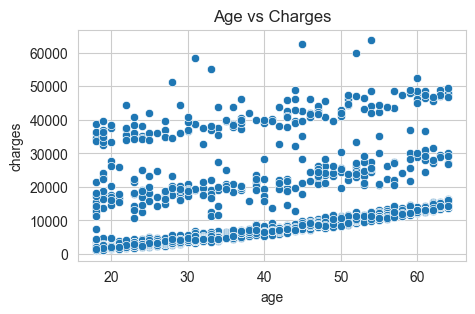

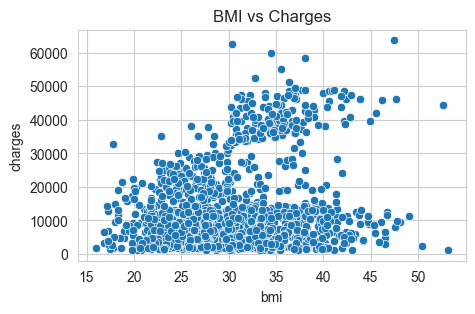

In [21]:
# 8. Numerical Relationships
plt.figure(figsize=(5, 3))
sns.scatterplot(x=df["age"], y=df["charges"])
plt.title("Age vs Charges")
plt.show()

plt.figure(figsize=(5, 3))
sns.scatterplot(x=df["bmi"], y=df["charges"])
plt.title("BMI vs Charges")
plt.show()

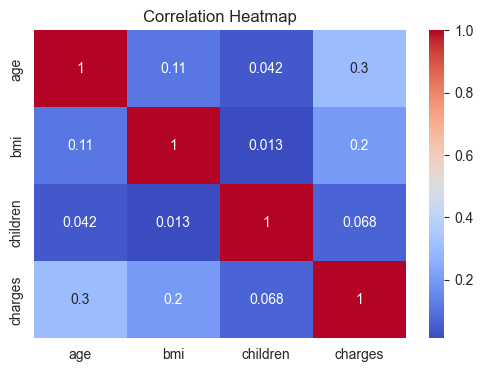


EDA Completed


In [22]:
# 9. Correlation Heatmap (Bonus)
plt.figure(figsize=(6, 4))
sns.heatmap(df[num_cols].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

print("\nEDA Completed")

## 10. Summary of Insights

- The dataset loads cleanly with no missing values and very few (if any) duplicate rows, so basic data quality is good.
- Numerical variables (`age`, `bmi`, `children`, `charges`) show sensible ranges; `charges` is heavily right-skewed, indicating a small group of very high-cost patients.
- Categorical variables (`sex`, `smoker`, `region`) are reasonably balanced across categories, with smokers forming a smaller proportion of the population.
- Smokers have dramatically higher insurance charges than non-smokers, making smoking status one of the strongest visible drivers of cost.
- Charges tend to increase with age and with higher BMI: older individuals and those with higher BMI generally face higher medical expenses.
- Differences in charges by sex and region exist but appear smaller compared to the impact of smoking, age, and BMI.
- Correlation among numerical features is moderate overall, with `charges` most positively associated with `age` and `bmi`, supporting the visual patterns seen in the scatter plots.

Overall, the EDA suggests that lifestyle/health factors (smoking, BMI) and age are key determinants of medical insurance charges in this dataset, while demographic factors like sex and region play a relatively secondary role.